<div align="center">

# 🧬 Computer Assignment 2: Genetic Algorithm  
## 🎵 Melody Reconstruction using Evolution

**Course:** Artificial Intelligence   
<br>

**Student Name:** `Mohammad Hosein Kabiri Samani`  
**Student Number:** `810103496`  

</div>

---


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
import scipy.io.wavfile as wavfile
import random






## 🎧 Part 1: Melody Extraction

Before our Genetic Algorithm can start evolving, it needs a Target Sequence to compare itself against. 

The code provided below takes an audio file (`.wav`), cuts it into small chunks based on the `note_duration`, and uses the **Fast Fourier Transform (FFT)** to find the dominant frequency (pitch) in each chunk. 
- A frequency of `0` means silence.
- Other numbers (e.g., `440`, `262`) represent musical notes.




### Extracting Frequencies from Audio


In [2]:
def extract_frequencies_from_wav(filename, note_duration, sample_rate=44100):
    sr, data = wavfile.read(filename)
    chunk_samples = int(sr * note_duration)
    extracted_freqs = []
    num_chunks = len(data) // chunk_samples
    max_amplitude = np.max(np.abs(data))
    silence_threshold = max_amplitude * 0.05   

    for i in range(num_chunks):
        start = i * chunk_samples
        end = start + chunk_samples
        chunk = data[start:end]
        
        if np.max(np.abs(chunk)) < silence_threshold:
            extracted_freqs.append(0)
            continue
            
        mid_start = int(0.20 * len(chunk))
        mid_end = int(0.80 * len(chunk))
        focus_chunk = chunk[mid_start:mid_end]
        
        window = np.hanning(len(focus_chunk))
        windowed_chunk = focus_chunk * window
        
        N_padded = sample_rate * 2 
        
        fft_result = np.fft.fft(windowed_chunk, n=N_padded)
        freqs = np.fft.fftfreq(N_padded, 1/sr)
        
        pos_mask = (freqs > 20) & (freqs < 2000)
        fft_result = np.abs(fft_result[pos_mask])
        freqs = freqs[pos_mask]
        
        if len(fft_result) == 0:
            extracted_freqs.append(0)
            continue
            
        peak_idx = np.argmax(fft_result)
        peak_freq = freqs[peak_idx]
        
        extracted_freqs.append(int(round(peak_freq)))

    while extracted_freqs and extracted_freqs[-1] == 0:
        extracted_freqs.pop()

    return extracted_freqs

if __name__ == "__main__":

    path1 = "musics/got_target.wav"
    path2 = "musics/interstellar_target.wav"
    path3 = "musics/harry_potter_target.wav"
    path4 = "musics/bella_ciao_target.wav"
    path5 = "musics/mario_target.wav"
    path6 = "musics/pink_panther_target.wav"
    path7 = "musics/fur_elise_target.wav"
    path8 = "musics/swan_lake_target.wav"
    path9 = "musics/squid_game_target.wav"

    songs = {
        path1: 0.25,
        path2: 0.25,
        path3: 0.25,
        path4: 0.25,
        path5: 0.20,
        path6: 0.25,
        path7: 0.30,
        path8: 0.30,
        path9: 0.30
    }
    test_file = path1
    duration = songs[test_file]
    target_frequencies = extract_frequencies_from_wav(test_file, note_duration=duration)
    print(f"Target Array Length: {len(target_frequencies)}")
    print(target_frequencies)


Target Array Length: 46
[392, 262, 311, 349, 392, 262, 311, 349, 294, 294, 0, 0, 349, 233, 262, 294, 349, 233, 262, 294, 262, 262, 0, 0, 392, 262, 311, 349, 392, 262, 311, 349, 440, 440, 0, 0, 349, 233, 262, 294, 349, 233, 262, 294, 262, 262]


# <span style="color: #3498db;">Genetic Algorithm</span>

---
## 🧬 Part 2: Implementing the Genetic Algorithm Class

For this assignment, you will implement the core components of a Genetic Algorithm within a structured class. This approach helps in organizing the evolutionary process.

A `GeneticAlgorithm` class will manage the population and the evolutionary steps. You will need to implement the methods for initialization, fitness calculation, selection, crossover, and mutation.


<div style="font-size: 1.2em; font-weight: bold; margin-bottom: 5px;">⚠️ Important Note on Performance:</div>  
Using <b>NumPy arrays</b> for all operations is crucial for efficiency. Vectorized operations are significantly faster than standard Python loops. Aim to implement your logic using NumPy functions wherever possible.
</div>


In [3]:
class GeneticAlgorithm:
    def __init__(self, target_frequencies, pop_size, generations, mutation_rate, min_freq=0, max_freq=2000):
        """
        Initializes the Genetic Algorithm.
        """
        self.target_frequencies = target_frequencies
        self.pop_size = pop_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.chromosome_length = len(target_frequencies)
        self.min_freq = min_freq
        self.max_freq = max_freq
        
        # We will store the history of the best fitness score in each generation
        self.best_fitness_history = []
        self.best_chromosome = None
        
        # Initialize the first population
        self.population = self._initialize_population()

    def _initialize_population(self):
        
        
        initial_population =  np.random.randint(low=self.min_freq , high=self.max_freq + 1 , size=(self.pop_size , self.chromosome_length))
        return initial_population
        
        """
        Creates the initial random population.
        Returns:
            np.array: Population array of shape (pop_size, chromosome_length).
        """
        # DONE: Implement population initialization using NumPy

    def _calculate_fitness(self , method):
        
        fitness_scores = np.zeros(self.pop_size)
        if method =="ABS distance Average" :
            errors = np.mean(np.abs(self.population -self.target_frequencies), axis=1)
            fitness_scores = 1/(errors + 1e-10)
        elif method =="Match":
            fitness_scores =np.sum(self.population == self.target_frequencies , axis=1)
        elif method =='Var':
            errors= np.mean((self.population - self.target_frequencies)**2, axis=1)
            fitness_scores = 1/ (errors + 1e-10)
        elif method=="Logarithm" :
            log_population = np.log(1e-10 + self.population)
            log_target_frequencies = np.log(1e-10 + self.target_frequencies)
            errors = np.mean(np.abs(log_population - log_target_frequencies) , axis=1)
            fitness_scores = 1 / (errors + 1e-10)
        return fitness_scores
        """
        Calculates the fitness score for each individual in the population.
        Fitness should be inversely proportional to the error (e.g., MAE).
        Returns:
            np.array: Fitness scores for the current population.
        """
        # DONE: Calculate fitness based on the difference between individuals and target_frequencies

    def _selection(self, num_parents , fitness_scores , tournament_size = 3):
        chromosome_length = self.population.shape[1]
        population_size= self.population.shape[0]
        parrents = np.zeros((num_parents , chromosome_length))
        for parrent_index in range (num_parents) :
            tournament_index = np.random.choice(population_size , tournament_size , replace=False)
            tournament_fitness = fitness_scores[tournament_index]
            most_index_tournament = np.argmax(tournament_fitness)
            actual_most_index = tournament_index[most_index_tournament]
            parrents[parrent_index  , : ] =self.population[actual_most_index, : ]
        return parrents
    
        """
        Selects parents for the next generation.
        You can use methods like Tournament Selection or Roulette Wheel.
        
        Args:
            num_parents (int): Number of parents to select.
        Returns:
            np.array: Selected parents.
        """
        # DONE: Implement parent selection
        

    def _crossover(self, parents, offspring_size):
        
        chromosome_length = parents.shape[1]
        num_parents = parents.shape[0]
        
        offspring = np.zeros((offspring_size , chromosome_length))
        
        for i in range (offspring_size) :
            parent_1_index = i % num_parents
            parrent_2_index = (i + 1) % num_parents
            crossover_point = np.random.randint(1 , chromosome_length)
            offspring[i , 0 : crossover_point ] = parents[parent_1_index , 0 : crossover_point]
            offspring[i , crossover_point :  ] = parents[parrent_2_index , crossover_point : ]
        
        return offspring
        
        """
        Performs crossover between selected parents to create offspring.
        (e.g., Single-Point or Two-Point Crossover)
        
        Args:
            parents (np.array): Selected parent chromosomes.
            offspring_size (int): Number of offspring to generate.
        Returns:
            np.array: Generated offspring.
        """
        # DONE: Implement crossover strategy
    

    def _mutation(self, offspring):
        random_mutation_probablity = np.random.rand(offspring.shape[0], offspring.shape[1])
        compare_mutation_rate = random_mutation_probablity < self.mutation_rate
        random_frequencies = np.random.randint(low=self.min_freq , high=self.max_freq, size=offspring.shape)
        offspring[compare_mutation_rate] = random_frequencies[compare_mutation_rate]
        return offspring
        """
        Applies random mutations to the offspring based on mutation_rate.
        
        Args:
            offspring (np.array): The newly generated offspring chromosomes.
        Returns:
            np.array: Mutated offspring.
        """
        # DONE: Implement mutation strategy

    def run(self):
        best_overall_fitness = -float('inf')
        for generation in range(self.generations) : 
            fitness_scores = self._calculate_fitness("ABS distance Average")
            best_index = np.argmax(fitness_scores)
            best_fitness = fitness_scores[best_index]
            self.best_fitness_history.append(best_fitness)
            if(best_fitness > best_overall_fitness) :
                best_overall_fitness = best_fitness
                self.best_chromosome = self.population[best_index].copy()
                
            if generation % 10 ==0 :
                print(f"Generation {generation} :  Best Fitness = {best_fitness:.4f} ")
                
            parents = self._selection(num_parents=self.pop_size ,fitness_scores=fitness_scores, tournament_size=3)
            offspring = self._crossover(parents=parents ,offspring_size=self.pop_size)
            mutated_offspring = self._mutation(offspring=offspring)
            mutated_offspring[0] = self.best_chromosome.copy()
            self.population = mutated_offspring
        print(f"Best fitness: {best_overall_fitness:.4f}")
        return self.best_chromosome
        
        """
        Executes the main loop of the Genetic Algorithm.
        """
        # DONE: Implement the main evolutionary loop
        # For each generation:
        # 1. Calculate fitness
        # 2. Find and save the best individual
        # 3. Select parents
        # 4. Generate offspring via crossover
        # 5. Apply mutation
        # 6. Replace the old population with the new one



---
## Part 3: Visualization

Numbers are good, but plots are better! 
In this section, you need to plot your Best Chromosome against the Target Frequencies. 
Use a line plot or a step plot. This visual overlap will quickly show you which notes your algorithm successfully learned and which ones it missed.


Generation 0 :  Best Fitness = 0.0018 
Generation 10 :  Best Fitness = 0.0031 
Generation 20 :  Best Fitness = 0.0058 
Generation 30 :  Best Fitness = 0.0074 
Generation 40 :  Best Fitness = 0.0082 
Generation 50 :  Best Fitness = 0.0103 
Generation 60 :  Best Fitness = 0.0108 
Generation 70 :  Best Fitness = 0.0108 
Generation 80 :  Best Fitness = 0.0121 
Generation 90 :  Best Fitness = 0.0153 
Generation 100 :  Best Fitness = 0.0155 
Generation 110 :  Best Fitness = 0.0155 
Generation 120 :  Best Fitness = 0.0155 
Generation 130 :  Best Fitness = 0.0158 
Generation 140 :  Best Fitness = 0.0162 
Generation 150 :  Best Fitness = 0.0163 
Generation 160 :  Best Fitness = 0.0163 
Generation 170 :  Best Fitness = 0.0163 
Generation 180 :  Best Fitness = 0.0163 
Generation 190 :  Best Fitness = 0.0163 
Generation 200 :  Best Fitness = 0.0193 
Generation 210 :  Best Fitness = 0.0193 
Generation 220 :  Best Fitness = 0.0194 
Generation 230 :  Best Fitness = 0.0194 
Generation 240 :  Best Fitn

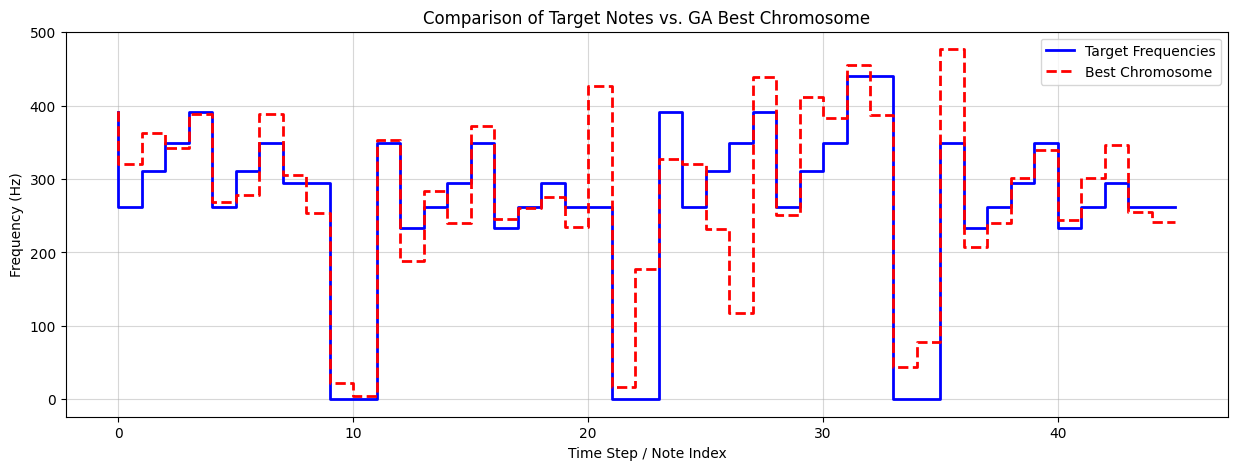

In [4]:
ga = GeneticAlgorithm(
    target_frequencies=target_frequencies,
    pop_size=500,
    mutation_rate=0.05,
    generations=500
)

# ۲. اجرای الگوریتم و ذخیره بهترین کروموزوم
best_chromosome = ga.run()

plt.figure(figsize=(15, 5))

# رسم نت‌های هدف
plt.step(range(len(target_frequencies)), target_frequencies, label='Target Frequencies', color='blue', linewidth=2)

# رسم بهترین کروموزوم پیدا شده توسط الگوریتم ژنتیک
plt.step(range(len(best_chromosome)), best_chromosome, label='Best Chromosome', color='red', linestyle='--', linewidth=2)

plt.title('Comparison of Target Notes vs. GA Best Chromosome')
plt.xlabel('Time Step / Note Index')
plt.ylabel('Frequency (Hz)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# TODO: Plot the Target array and your Best Chromosome array on the same figure.
# Add legends, title, and labels to make it professional.




---
## 🎵 Part 4: The Ultimate Test (Listen to Your Algorithm)

Has your Genetic Algorithm learned to play music? Let's find out!
The function below takes your array of frequencies and synthesizes it into a real audio file using sine waves, harmonics, vibrato, and echo effects.

**Instructions:**
1. Run the synthesis function.
2. Pass your `best_chromosome` to this function.
3. Open the generated `.wav` file and listen to it! 
*(Make sure to use the exact same `note_duration` that was used to extract the target frequencies).*


In [5]:
from scipy.io import wavfile

def frequencies_to_melody(frequencies, output_filename="ai_melody_clean.wav", note_duration=0.25, sample_rate=44100):
    """Generates a clean, standard synth sound (Good for checking accuracy)."""
    print(f"Synthesizing Clean Audio: {output_filename}")
    audio_signal = []    
    t = np.linspace(0, note_duration, int(sample_rate * note_duration), False)
    envelope = np.ones_like(t)
    attack_len = int(0.05 * len(t))
    envelope[:attack_len] = np.linspace(0, 1, attack_len)
    envelope[attack_len:] = np.exp(-3.5 * np.linspace(0, 1, len(t) - attack_len))
    
    for freq in frequencies:
        if freq > 10: 
            wave = np.sin(2 * np.pi * freq * t)              
            wave += 0.5 * np.sin(2 * np.pi * (freq * 2) * t) 
            wave += 0.25 * np.sin(2 * np.pi * (freq * 3) * t)  
            wave = wave * envelope
        else:
            wave = np.zeros_like(t)
        audio_signal.extend(wave)
        
    audio_signal = np.array(audio_signal)
    max_val = np.max(np.abs(audio_signal))
    if max_val > 0:
        audio_signal = audio_signal / max_val        
    fade_out_len = int(sample_rate * 0.1)
    if len(audio_signal) > fade_out_len:
        audio_signal[-fade_out_len:] *= np.linspace(1, 0, fade_out_len)
    audio_int16 = np.int16(audio_signal * 32767 * 0.8)
    wavfile.write(output_filename, sample_rate, audio_int16)

def frequencies_to_melody_ultimate(frequencies, output_filename="ai_melody_ultimate.wav", note_duration=0.25, sample_rate=44100):
    """Generates a rich, professional sound with Vibrato and Echo (The Grand Prize!)."""
    print(f"Synthesizing Ultimate Audio: {output_filename}")
    audio_signal = []
    t = np.linspace(0, note_duration, int(sample_rate * note_duration), False)
    
    envelope = np.ones_like(t)
    attack = int(0.05 * len(t))
    envelope[:attack] = np.linspace(0, 1, attack)
    envelope[attack:] = np.exp(-4 * np.linspace(0, 1, len(t) - attack))
    
    for freq in frequencies:
        if freq > 10:
            vibrato_rate = 5.0 
            vibrato_depth = 0.01 * freq 
            vibrato = np.sin(2 * np.pi * vibrato_rate * t) * vibrato_depth
            
            wave = np.sin(2 * np.pi * (freq + vibrato) * t)                 
            wave += 0.4 * np.sin(2 * np.pi * (freq * 2 + vibrato) * t)      
            wave += 0.2 * np.sin(2 * np.pi * (freq * 3 + vibrato) * t)      
            wave = wave * envelope
        else:
            wave = np.zeros_like(t)
        audio_signal.extend(wave)
        
    audio_signal = np.array(audio_signal)
    
    delay_samples = int(sample_rate * 0.3) 
    echo_signal = np.zeros(len(audio_signal) + delay_samples)
    echo_signal[:len(audio_signal)] = audio_signal
    echo_signal[delay_samples:] += audio_signal * 0.35 
    
    max_val = np.max(np.abs(echo_signal))
    if max_val > 0:
        echo_signal = echo_signal / max_val
        
    audio_int16 = np.int16(echo_signal * 32767 * 0.8)
    wavfile.write(output_filename, sample_rate, audio_int16)
    print("Done!\n")


# ==========================================
# TODO: Choose your duration based on the song you extracted (e.g., 0.25 for Super Mario, 0.5 for Game of Thrones)
# Here we use the note_duration you defined earlier.

NOTE_DURATION = 0.25

frequencies_to_melody(best_chromosome, "my_ai_melody_clean.wav", note_duration=NOTE_DURATION)

frequencies_to_melody_ultimate(best_chromosome, "my_ai_melody_ultimate.wav", note_duration=NOTE_DURATION)


Synthesizing Clean Audio: my_ai_melody_clean.wav
Synthesizing Ultimate Audio: my_ai_melody_ultimate.wav
Done!



<div dir="ltr" style="text-align: left;">

**Q1: Calculate the number of possible states for the chromosomes and approximate it as a power of 10.**

Assuming each chromosome has $f$ positions (genes) and there are $2000$ possible choices for each frequency, the total number of unique chromosomes (the search space) is $2000^f$.

To approximate this as a power of 10:

$$2000^f = (2 \times 10^3)^f \approx (10^{0.3} \times 10^3)^f = 10^{3.3 \times f}$$

*(Note: You just need to substitute the exact value of $f$ from your code into $10^{3.3 \times f}$ to get the final numerical power).*

</div>


<div dir="ltr" style="text-align: left;">

**Q2: What is the problem with using an indirect fitness metric (e.g., sum of differences between adjacent frequencies) instead of a direct metric (e.g., distance to target frequencies)?**

A Genetic Algorithm acts as a strict optimizer—it will maximize or minimize exactly the mathematical function you provide. If you use an indirect metric, the GA will simply exploit it, often leading to unintended results. For example, if you penalize the difference between adjacent frequencies to make the melody "smoother," the absolute easiest way for the GA to achieve a perfect score of 0 is to output a single, constant frequency (a flat tone). This perfectly satisfies the indirect metric but completely ignores the actual goal of replicating the target melody. Direct metrics ensure the algorithm is explicitly rewarded only when it gets closer to the true objective.

---

**Q3: Between Roulette Wheel Selection and Tournament Selection, which one generally maintains more genetic diversity in the population, and why?**

**Roulette Wheel Selection** generally maintains more genetic diversity. In Roulette Wheel, the probability of selection is proportional to an individual's fitness. This means that even the weakest individuals in the population have a non-zero chance of being selected and passing on their genes to the next generation. 

In contrast, **Tournament Selection** randomly picks a subset of individuals and chooses the best among them. Weak individuals will almost always lose their tournaments and be entirely excluded from reproduction, leading to a much faster loss of diversity, especially if the tournament size is large.

---

**Q4: What happens if the percentage of Elitism is set too high?**

Elitism ensures that the best solutions are safely carried over to the next generation without being destroyed by crossover or mutation. However, if the elitism rate is set too high, a large portion of the population remains identical from generation to generation. This drastically reduces the number of new offspring being generated and limits the introduction of new genetic material. As a result, the population quickly loses genetic diversity and becomes highly prone to **premature convergence**, meaning the algorithm gets permanently trapped in a local optimum instead of finding the global best solution.

---

**Q5: Discuss the effects of having a very low versus a very high mutation rate.**

*   **Very Low Mutation Rate:** The algorithm will rely almost entirely on crossover to explore the search space. Since crossover only recombines existing genes, it cannot create entirely new ones. If the initial population is missing crucial genetic information needed to find the target, the algorithm will never be able to discover it, leading to stagnation and premature convergence.
*   **Very High Mutation Rate:** The evolutionary process degrades into a **purely random search**. While high mutation introduces massive diversity, it constantly destroys the good genetic sequences (building blocks) that selection and crossover have worked hard to assemble. Consequently, the algorithm will struggle to converge on a stable, optimal solution.

</div>
